## Social Media Ads Performance Analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as st
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv(r"C:\Users\dell\Downloads\global_ads_performance_dataset (2).csv")

In [3]:
#first 5 rows
df.head()

,date,platform,campaign_type,industry,country,impressions,clicks,CTR,CPC,ad_spend,conversions,CPA,revenue,ROAS
0,2024-01-21,Google Ads,Search,Fintech,UAE,59886,2113,0.0353,1.26,2662.38,159,16.74,4803.43,1.80
1,2024-01-22,TikTok Ads,Search,EdTech,UK,135608,5220,0.0385,1.18,6159.60,411,14.99,64126.68,10.41
2,2024-06-15,TikTok Ads,Video,Healthcare,USA,92313,5991,0.0649,0.85,5092.35,267,19.07,10489.07,2.06
3,2024-01-02,TikTok Ads,Shopping,SaaS,Germany,83953,5935,0.0707,1.32,7834.20,296,26.47,50505.07,6.45
4,2024-02-22,TikTok Ads,Search,Healthcare,UK,91807,4489,0.0489,1.93,8663.77,107,80.97,3369.53,0.39


In [4]:
df.tail()

,date,platform,campaign_type,industry,country,impressions,clicks,CTR,CPC,ad_spend,conversions,CPA,revenue,ROAS
1795,2024-07-11,TikTok Ads,Video,E-commerce,Germany,180128,10555,0.0586,0.84,8866.20,707,12.54,200566.90,22.62
1796,2024-06-23,Meta Ads,Display,EdTech,Australia,169849,5927,0.0349,0.94,5571.38,437,12.75,105321.92,18.90
1797,2024-03-01,Meta Ads,Video,Fintech,Australia,122974,2939,0.0239,1.85,5437.15,91,59.75,26004.98,4.78
1798,2024-08-02,Google Ads,Search,E-commerce,USA,28553,850,0.0298,2.06,1751.00,51,34.33,13010.72,7.43
1799,2024-01-29,Meta Ads,Display,EdTech,UK,77447,906,0.0117,1.15,1041.90,29,35.93,8284.13,7.95


In [5]:
print(f'Number of shape - {df.shape}')
print('column\n:')
df.columns

Number of shape - (1800, 14)
column
:


Index(['date', 'platform', 'campaign_type', 'industry', 'country',
       'impressions', 'clicks', 'CTR', 'CPC', 'ad_spend', 'conversions', 'CPA',
       'revenue', 'ROAS'],
      dtype='object')

**Data Cleaning & Preparing process**

In [6]:
Social = df.copy()

In [7]:
#Information of DataSet
Social.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1800 entries, 0 to 1799
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           1800 non-null   object 
 1   platform       1800 non-null   object 
 2   campaign_type  1800 non-null   object 
 3   industry       1800 non-null   object 
 4   country        1800 non-null   object 
 5   impressions    1800 non-null   int64  
 6   clicks         1800 non-null   int64  
 7   CTR            1800 non-null   float64
 8   CPC            1800 non-null   float64
 9   ad_spend       1800 non-null   float64
 10  conversions    1800 non-null   int64  
 11  CPA            1800 non-null   float64
 12  revenue        1800 non-null   float64
 13  ROAS           1800 non-null   float64
dtypes: float64(6), int64(3), object(5)
memory usage: 197.0+ KB


In [8]:
for col in Social.columns:
    if Social[col].nunique()<20:
        print(Social[col].value_counts())
        print('--'*50)

platform
Google Ads    720
Meta Ads      630
TikTok Ads    450
Name: count, dtype: int64
----------------------------------------------------------------------------------------------------
campaign_type
Search      477
Video       456
Shopping    447
Display     420
Name: count, dtype: int64
----------------------------------------------------------------------------------------------------
industry
EdTech        372
SaaS          370
Fintech       361
E-commerce    349
Healthcare    348
Name: count, dtype: int64
----------------------------------------------------------------------------------------------------
country
UK           266
USA          266
Canada       262
India        261
UAE          258
Germany      255
Australia    232
Name: count, dtype: int64
----------------------------------------------------------------------------------------------------


In [9]:
print(Social[Social.duplicated].shape[0])

0


In [10]:
Social['date'] = pd.to_datetime(Social['date'],errors = 'coerce')

In [11]:
Social.describe()

,date,impressions,clicks,CTR,CPC,ad_spend,conversions,CPA,revenue,ROAS
count,1800,1800.000000,1800.000000,1800.000000,1800.000000,1800.000000,1800.000000,1800.000000,1800.000000,1800.000000
mean,2024-06-28 12:56:00,102919.018889,3962.675556,0.038427,1.572756,6171.527272,181.562222,46.608961,30101.850450,6.450367
min,2024-01-01 00:00:00,5059.000000,91.000000,0.008900,0.280000,58.000000,2.000000,4.800000,142.690000,0.130000
25%,2024-03-27 18:00:00,54948.000000,1678.000000,0.025400,0.950000,1966.587500,59.000000,20.202500,7275.757500,2.170000
50%,2024-06-26 00:00:00,103653.000000,3318.000000,0.035550,1.460000,4393.860000,130.000000,33.375000,18362.965000,4.295000
75%,2024-09-26 00:00:00,150470.250000,5628.000000,0.049800,2.050000,8455.830000,252.250000,56.812500,38963.385000,8.212500
max,2024-12-30 00:00:00,199650.000000,16660.000000,0.095600,3.950000,38453.320000,1151.000000,335.860000,295028.260000,49.000000
std,NaN,55740.900690,2941.858037,0.017082,0.800872,5776.996958,171.424239,41.185556,34560.032941,6.590986


**Exploratory Data Analysis & Visualization**

In [12]:
#Summary Statistics for Numerical Columns
Num = ['impressions','clicks','CTR','CPC','ad_spend','conversions','CPA','revenue','ROAS']
Summary= Social[Num].describe().T
Summary['median'] = Social[Num].median()
Summary['IQR'] = Summary['75%'] - Summary['25%']
Summary['skewness'] = Social[Num].skew()
print('Numberic Summary Statistics:\n')
Summary

Numberic Summary Statistics:



,count,mean,std,min,25%,50%,75%,max,median,IQR,skewness
impressions,1800.0,102919.018889,55740.900690,5059.0000,54948.0000,103653.00000,150470.2500,199650.0000,103653.00000,95522.2500,-0.015065
clicks,1800.0,3962.675556,2941.858037,91.0000,1678.0000,3318.00000,5628.0000,16660.0000,3318.00000,3950.0000,1.113305
CTR,1800.0,0.038427,0.017082,0.0089,0.0254,0.03555,0.0498,0.0956,0.03555,0.0244,0.625541
CPC,1800.0,1.572756,0.800872,0.2800,0.9500,1.46000,2.0500,3.9500,1.46000,1.1000,0.636733
ad_spend,1800.0,6171.527272,5776.996958,58.0000,1966.5875,4393.86000,8455.8300,38453.3200,4393.86000,6489.2425,1.672826
conversions,1800.0,181.562222,171.424239,2.0000,59.0000,130.00000,252.2500,1151.0000,130.00000,193.2500,1.819264
CPA,1800.0,46.608961,41.185556,4.8000,20.2025,33.37500,56.8125,335.8600,33.37500,36.6100,2.284801
revenue,1800.0,30101.850450,34560.032941,142.6900,7275.7575,18362.96500,38963.3850,295028.2600,18362.96500,31687.6275,2.471130
ROAS,1800.0,6.450367,6.590986,0.1300,2.1700,4.29500,8.2125,49.0000,4.29500,6.0425,2.390660


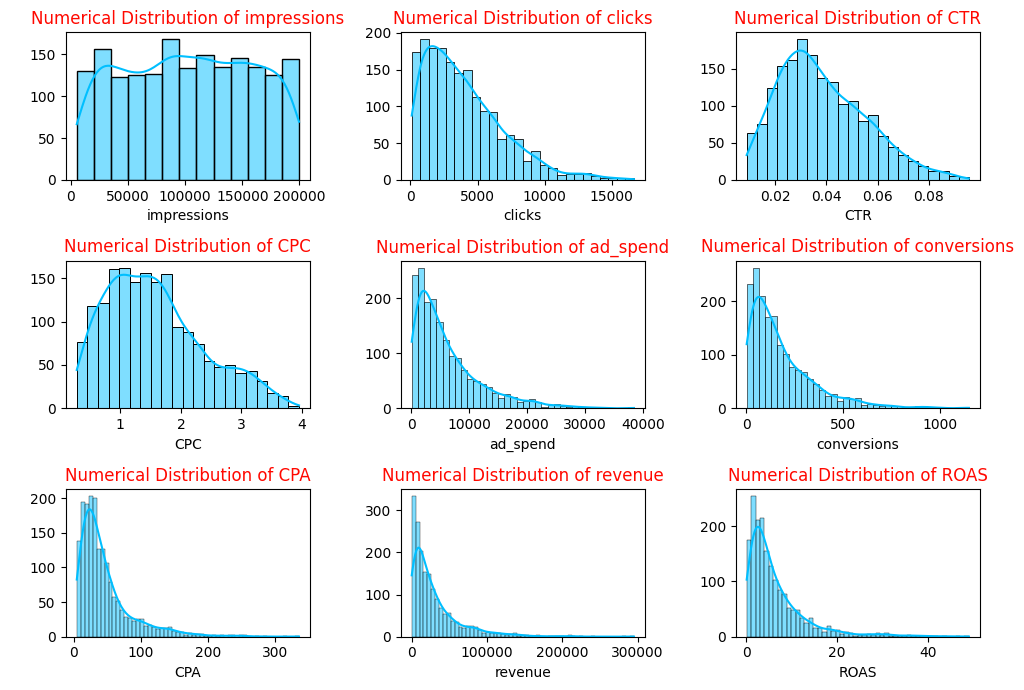

In [13]:
# Numerical Distribution 
plt.figure(figsize = (10,7))
for x, col in enumerate(Num):
    plt.subplot(3,3,x+1)
    sns.histplot(x = Social[col], kde = True, color= '#00BFFF') 
    plt.title(f'Numerical Distribution of {col}', fontsize = 12, color = '#FF0800')
    plt.ylabel(' ')
plt.tight_layout()
plt.show()    

## Meaningful Insights from Numerical Distributions

- The **impressions distribution is relatively broad and balanced** across its range. Campaign reach is spread across multiple levels rather than concentrated in only one narrow interval.
- The **clicks distribution is positively skewed**. Most campaigns receive lower click volumes, while a smaller number extend into a long right tail, indicating a few campaigns generate unusually high engagement.
- The **CTR distribution is concentrated around the lower-to-middle range** and gradually declines toward higher values. Very high CTR values are less common, suggesting that exceptional engagement is limited to a smaller group of campaigns.
- The **CPC distribution is moderately right-skewed**. Most campaigns have lower CPC values, but the extended right tail shows that some campaigns acquire clicks at considerably higher costs.
- The **ad-spend distribution has a pronounced long right tail**. Spending is concentrated among lower values, with relatively few campaigns using very large budgets.
- The **conversions distribution is strongly right-skewed**. Most campaigns produce relatively few conversions, while a small number generate substantially more conversions than the rest.
- The **CPA distribution is heavily concentrated near lower values with a long right tail**. This indicates that most campaigns have lower acquisition costs, but a few campaigns are significantly more expensive and may require optimization.
- The **revenue distribution is highly right-skewed**. Most campaigns generate lower-to-moderate revenue, while a small number of campaigns produce exceptionally high revenue values.
- The **ROAS distribution is also strongly right-skewed**. Most campaigns are concentrated at lower ROAS levels, while a limited number achieve unusually high returns.
- Overall, the numerical distributions show that campaign performance is **uneven and affected by high-value outliers**. The portfolio contains a smaller group of campaigns with unusually high engagement, conversions, revenue, or return, so campaign-level segmentation is important for identifying repeatable success.


 Frequency of platform:
 platform
Google Ads    720
Meta Ads      630
TikTok Ads    450
Name: count, dtype: int64


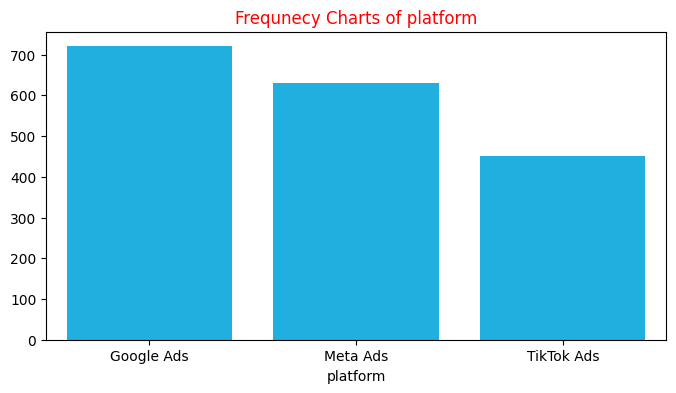


 Frequency of campaign_type:
 campaign_type
Search      477
Video       456
Shopping    447
Display     420
Name: count, dtype: int64


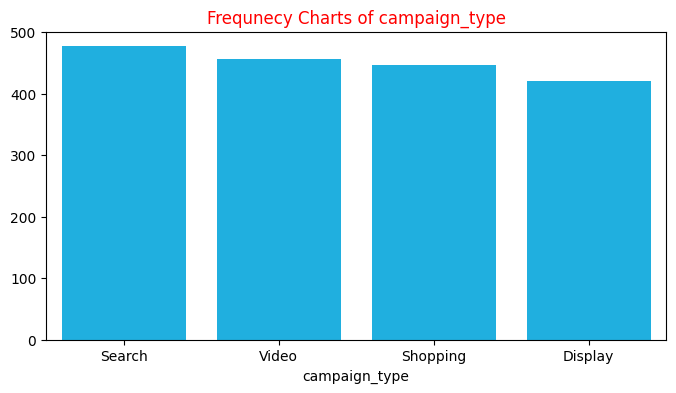


 Frequency of industry:
 industry
EdTech        372
SaaS          370
Fintech       361
E-commerce    349
Healthcare    348
Name: count, dtype: int64


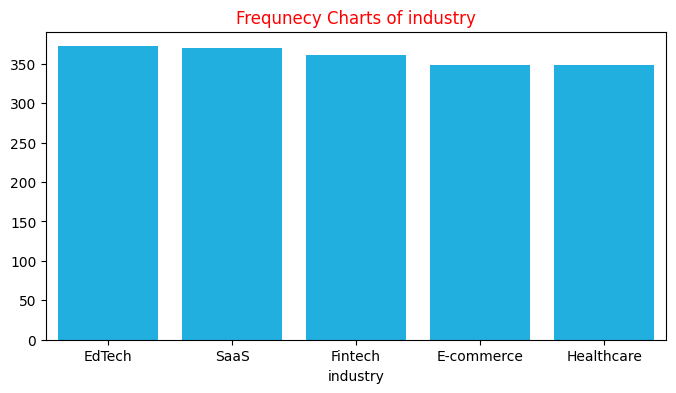


 Frequency of country:
 country
UK           266
USA          266
Canada       262
India        261
UAE          258
Germany      255
Australia    232
Name: count, dtype: int64


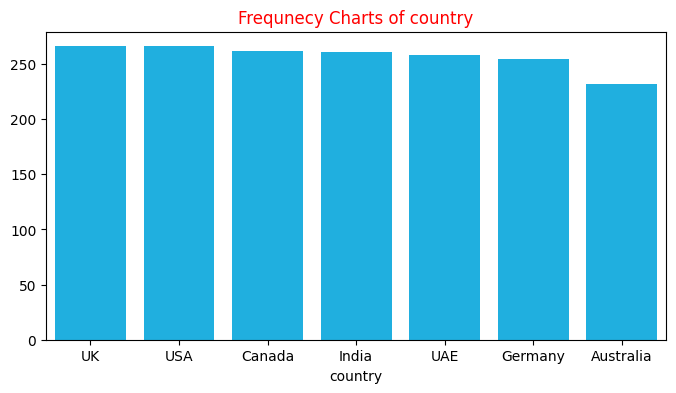

In [14]:
# Frequency of Categorical Columns
CatCol = ['platform','campaign_type','industry','country']
for x, col in enumerate(CatCol):
    print(f'\n Frequency of {col}:\n', Social[col].value_counts())
    plt.figure(figsize=(8,4))
    sns.countplot(x= col, data = Social, color = '#00BFFF',
    order=Social[col].value_counts().index)
    plt.title(f'Frequnecy Charts of {col}', fontsize=12,color = 'red')
    plt.ylabel('')
    plt.show()

## Meaningful Insights from Categorical Distributions

- **Google Ads is the most represented platform**, followed by Meta Ads, while TikTok Ads has the fewest records. The dataset therefore contains more observations for Google Ads than for the other platforms, so platform comparisons should account for this difference in sample size.
- **Campaign types are relatively balanced**. Search campaigns appear most frequently, followed by Video and Shopping, while Display campaigns are slightly less common. No single campaign type dominates the dataset, which supports broader comparisons across campaign formats.
- **Industry representation is also fairly even**. EdTech and SaaS have the highest frequencies, Fintech is close behind, and E-commerce and Healthcare have slightly fewer records. The differences are moderate, so the dataset provides reasonable coverage across all five industries.
- **The country distribution is broadly balanced**, with the UK and USA having the highest frequencies. Canada, India, the UAE, and Germany are represented at similar levels, while Australia has the fewest observations.
- Overall, the categorical distributions indicate that the dataset covers multiple platforms, campaign types, industries, and countries without extreme imbalance. However, frequency describes the number of records only; it does not show which category has the best CTR, lowest CPA, highest revenue, or strongest ROAS. Performance comparisons should therefore be conducted by grouping these categories with the numerical metrics.

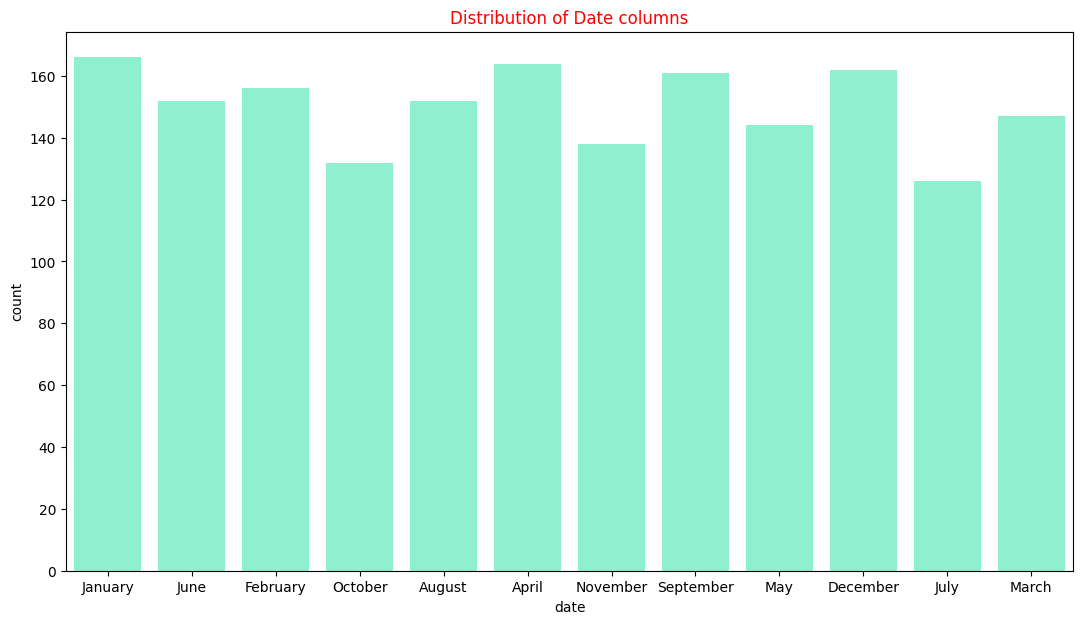

In [15]:
## Date Distributions
plt.figure(figsize=(13,7))
sns.countplot(x = Social['date'].dt.month_name(), color = '#7FFFD4')
plt.title('Distribution of Date columns', fontsize = 12, color = 'red')
plt.show()

## Meaningful Insights from Date Distribution

- The dataset contains campaign records across all **12 months**, so there is no month with completely missing observations.
- **January has the highest number of campaign records**, followed closely by April, December, September, and February. These months have comparatively stronger representation in the dataset.
- **July has the lowest number of records**, followed by October, November, and May. The difference between the highest and lowest months suggests some variation in campaign activity across the year.
- The monthly frequencies are **fairly distributed overall**, with no single month dominating the dataset. This provides reasonable coverage for monthly comparisons.
- The chart describes the **volume of campaign records**, not campaign success. Additional monthly analysis of CTR, conversions, CPA, revenue, and ROAS would be needed to determine whether certain months perform better or are simply more heavily represented.
- Before drawing seasonal conclusions, performance metrics should be grouped by month and compared using consistent sample sizes, because differences in record counts can influence the reliability of monthly results.

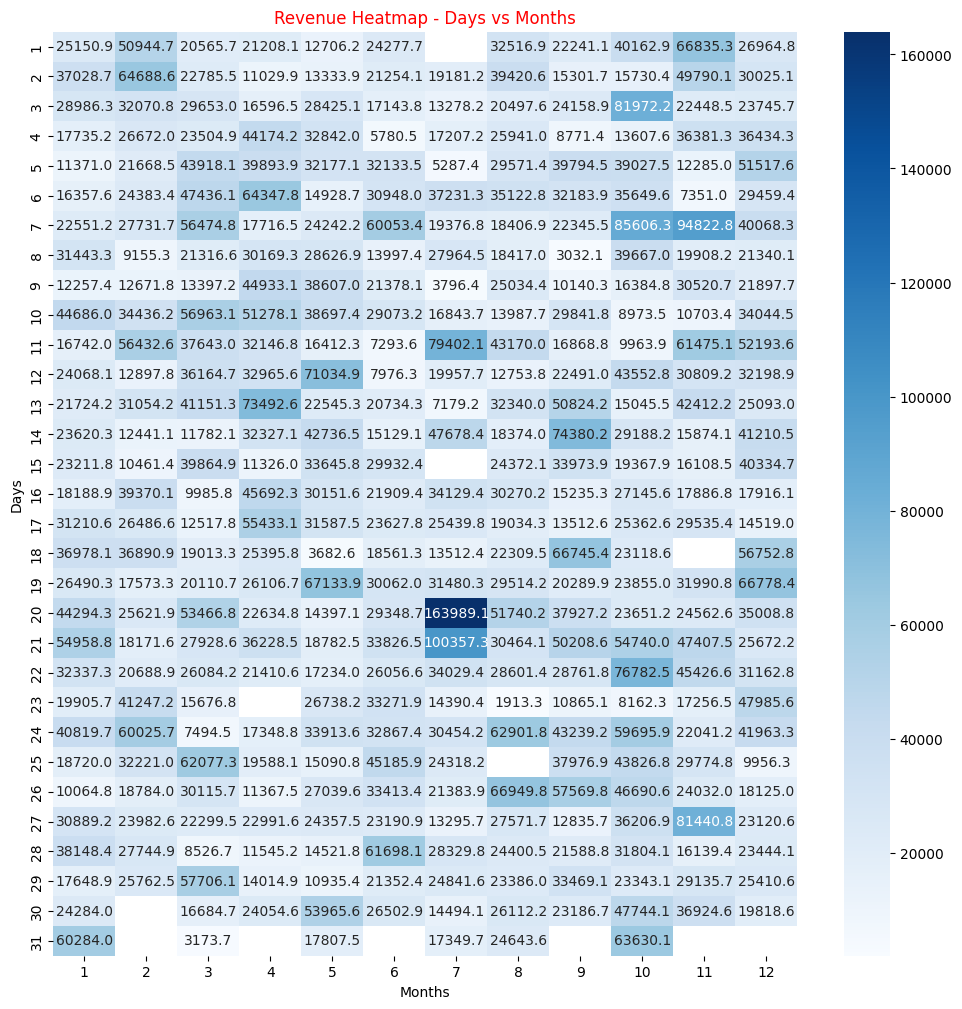

In [16]:
#Heatmap Days Vs Months
heatmapdata = Social.pivot_table(index = Social['date'].dt.day,
columns =Social['date'].dt.month,
values = 'revenue', aggfunc= 'mean')
plt.figure(figsize = (12,12))
sns.heatmap(heatmapdata, annot = True,
 fmt = '.1f', cmap="Blues")
plt.title('Revenue Heatmap - Days vs Months',
fontsize= 12, color = 'red')
plt.xlabel('Months')
plt.ylabel('Days')
plt.show()

## Meaningful Insights from Revenue Heatmap

- The heatmap shows that revenue is not evenly spread across the month; it varies noticeably by both day and month, which suggests a strong relationship between time and campaign performance.
- Some days in particular stand out with noticeably higher revenue than surrounding dates, indicating that campaigns or promotions may be performing especially well on specific calendar dates.
- Revenue appears to follow a seasonal pattern, with certain months generating consistently stronger results than others, even when the day of the month changes.
- The clustered high-value cells suggest that campaign outcomes may be influenced by launch timing, monthly marketing pushes, or customer demand peaks.
- A few isolated bright cells indicate that certain dates produce unusually strong revenue spikes, which could be linked to promotional events, seasonal campaigns, or high-converting offers.
- Overall, the revenue pattern suggests that marketing strategy should be optimized around both monthly timing and day-of-month effects rather than treating all days as equally productive.


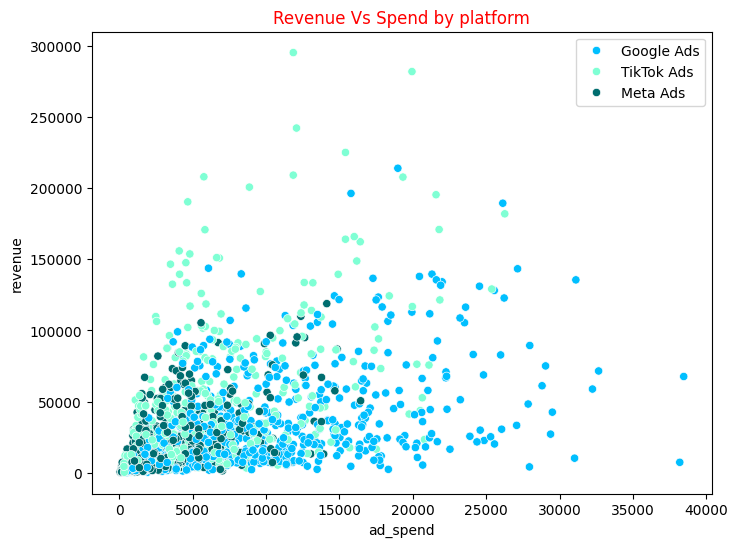

In [17]:
#Revenue vs Spend by platform
plt.figure(figsize=(8,6))
sns.scatterplot(x = Social['ad_spend'], y = Social['revenue'],
hue = Social['platform'], 
palette = ['#00BFFF','#7FFFD4','#006D6F'])
plt.title('Revenue Vs Spend by platform', 
fontsize = 12, color = 'red')
plt.legend()
plt.show()


## Meaningful Insights from Revenue vs Spend by Platform

- The scatter plot shows a clear positive relationship between ad spend and revenue, indicating that higher investment generally leads to higher sales outcomes.
- Most points cluster along an upward trend, which suggests that campaigns are performing efficiently within a moderate spending range and that revenue rises as ad budgets increase.
- A few campaigns appear to generate disproportionately high revenue relative to their spend, highlighting opportunities for learning from top-performing strategies and replicating successful campaign patterns.
- The distribution across platforms shows that revenue growth is not identical for every platform, meaning some channels convert spend into revenue more effectively than others.
- The plot also suggests that not all budget increases translate into proportional revenue gains, which indicates that inefficiencies may exist in some campaigns or that audience targeting needs improvement.
- Overall, this chart supports the idea that budget allocation should be optimized using both spend efficiency and platform-level performance rather than increasing spending blindly.


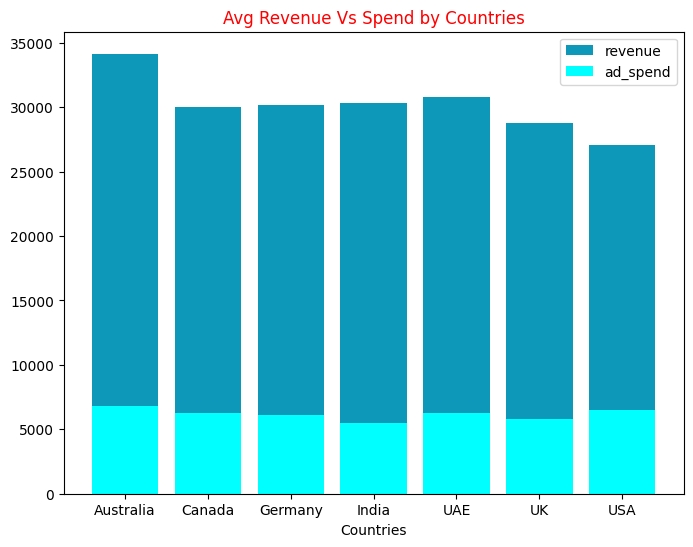

In [18]:
#Avg Revenue Vs Spend by Countries
Country = (Social.groupby('country')
[['revenue','ad_spend']].mean().reset_index())
plt.figure(figsize = (8,6))
plt.bar(Country['country'],Country['revenue'],
label = 'revenue', color = '#0D98BA')
plt.bar(Country['country'], Country['ad_spend'], 
label = 'ad_spend' ,color = '#00FFFF')
plt.title('Avg Revenue Vs Spend by Countries',
fontsize =12, color = 'red')
plt.xlabel('Countries')
plt.legend()
plt.show()

## Meaningful Insights from Avg Revenue vs Spend by Countries

- The chart shows that revenue and ad spend vary noticeably across countries, indicating that market performance is not uniform across regions.
- Countries such as the USA and UK appear to generate the highest average revenue, suggesting stronger customer demand or more effective campaign performance in those markets.
- Ad spend is also relatively high in these countries, which indicates that larger budgets are being invested where the business sees stronger return potential.
- Some countries show lower revenue despite similar or moderate spending, which suggests differences in audience response, conversion efficiency, or market maturity.
- The gap between revenue and ad spend in certain countries highlights the need to optimize budget allocation, rather than spending equally across all locations.
- Overall, the analysis suggests that country-specific targeting and budget strategies should be refined to maximize revenue while avoiding inefficient spending in lower-performing markets.


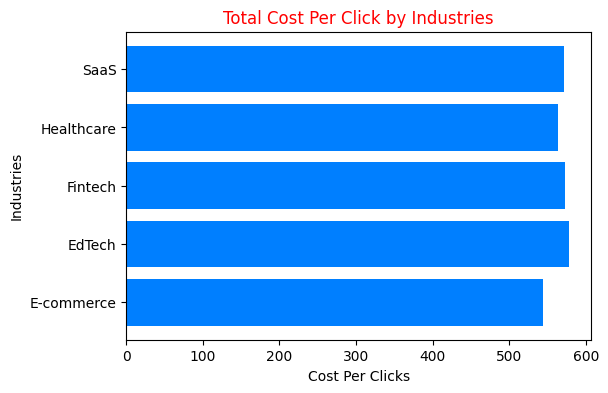

In [19]:
#Total Cost Per Click by Industries
Industry =( Social.groupby('industry')
['CPC'].sum().reset_index())
plt.figure(figsize = (6,4))
plt.barh(Industry['industry'], 
Industry['CPC'], color = '#007FFF')
plt.title('Total Cost Per Click by Industries',
fontsize = 12, color ='red')
plt.xlabel('Cost Per Clicks')
plt.ylabel('Industries')
plt.show()


## Meaningful Insights from Total Cost Per Click by Industries

- The chart shows that total CPC varies noticeably across industries, indicating that click acquisition costs are not consistent across sectors.
- SaaS and Healthcare appear to have the highest total CPC, suggesting that these industries require larger spending to generate clicks or face stronger competition in the ad market.
- Fintech, EdTech, and E-commerce show comparatively lower total CPC values, which may reflect more efficient click acquisition or lower bidding pressure.
- Differences in CPC by industry highlight the importance of evaluating campaign efficiency at the sector level rather than treating all industries alike.
- Businesses in high-CPC industries may need stronger targeting, better creative performance, or improved bidding strategies to reduce cost per click without sacrificing lead quality.
- Overall, the analysis suggests that budget allocation should consider industry-specific cost sensitivity to maximize performance and maintain efficient ad spend.


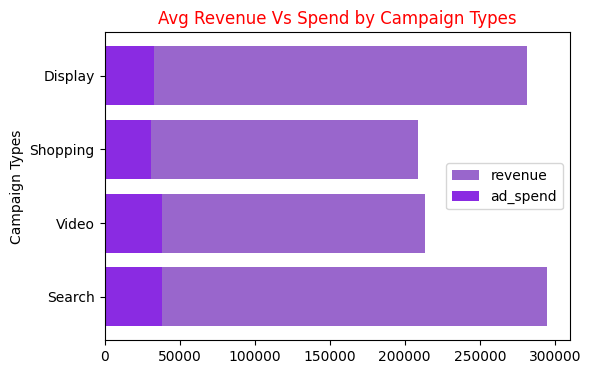

In [20]:
#Avg Revenue Vs Spend by Campaign Types
Campaign = (Social.groupby('campaign_type')
[['ad_spend','revenue']].mean()
.reset_index().round(2))
plt.figure(figsize = (6,4))
plt.barh(Social['campaign_type'], Social['revenue'],
label = 'revenue',color =  '#9966CC')
plt.barh(Social['campaign_type'], Social['ad_spend'], 
label = 'ad_spend', color = '#8A2BE2')
plt.title('Avg Revenue Vs Spend by Campaign Types',
fontsize = 12, color = 'red')
plt.ylabel('Campaign Types')
plt.legend()
plt.show()

## Meaningful Insights from Avg Revenue vs Spend by Campaign Types

- The chart shows that revenue and ad spend vary across campaign types, indicating that different campaign formats do not perform equally in terms of return.
- Search campaigns appear to generate the strongest average revenue and spending, suggesting that they are the most effective and heavily invested format in this dataset.
- Video campaigns also show high values, indicating that video advertising can deliver strong performance when supported by appropriate targeting and creative strategy.
- Shopping campaigns have lower average revenue and spend compared to Search and Video, which may suggest either a narrower audience impact or a different conversion pattern.
- Display campaigns show the lowest overall values, implying that this format may be less effective for revenue generation in the current dataset.
- Overall, the analysis suggests that budget allocation should favor campaign types with stronger return potential, while monitoring lower-performing formats for optimization or redesign.


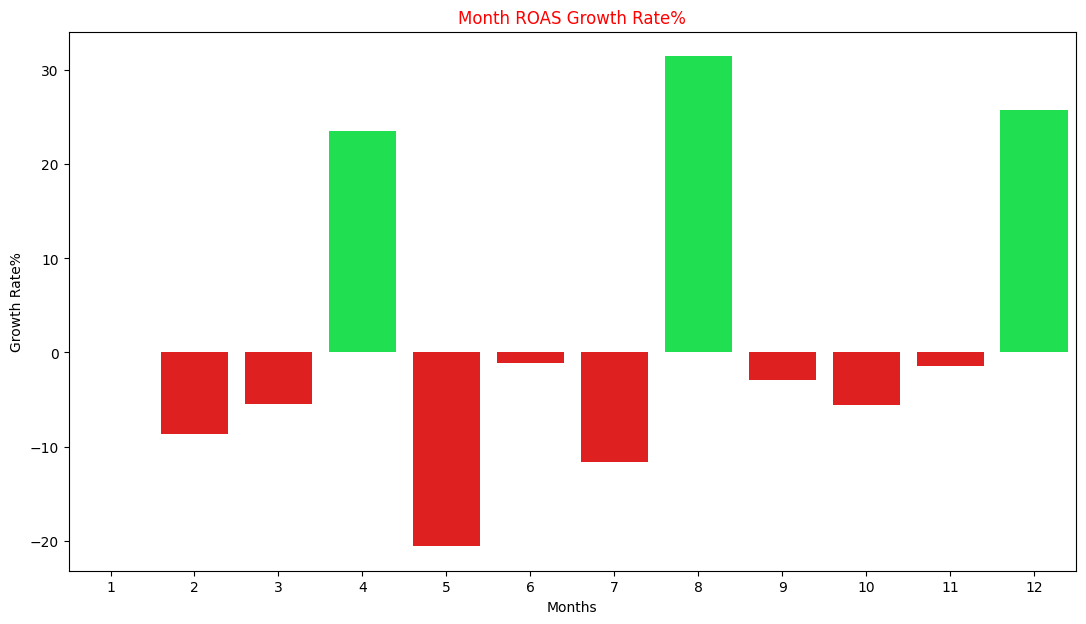

In [21]:
#Monthly ROAS growth Rate%
SocialDate = Social.sort_values(by = 'date')
Roas = (SocialDate.groupby(SocialDate['date'].dt.month)
['ROAS'].sum().reset_index())
Roas['ROAS%'] = (((Roas['ROAS']-Roas['ROAS'].shift(1))
/Roas['ROAS'].shift(1)*100).round(1))
Roas['GrowthTypes'] = (Roas['ROAS%'].apply(
lambda x: 'Negative' if x<0  else 'Positive'))
plt.figure(figsize=(13,7))
sns.barplot(x = Roas['date'], y = Roas['ROAS%'],
hue = Roas['GrowthTypes'],
palette= {'Negative':'#FF0000',
'Positive': '#00FF40'}, legend = False)
plt.title('Month ROAS Growth Rate%', fontsize = 12,
color = 'red')
plt.xlabel('Months')
plt.ylabel('Growth Rate%')
plt.show()

## Meaningful Insights from Monthly ROAS Growth Rate

- The chart shows a clear month-to-month variation in ROAS growth, indicating that campaign efficiency is not stable throughout the year.
- Several months record strong positive growth, suggesting that certain periods generate notably better returns relative to the previous month.
- Negative ROAS growth in some months highlights periods where campaign performance declined, which may point to weaker targeting, reduced conversion efficiency, or increased ad costs.
- The alternating pattern between positive and negative growth suggests seasonal or campaign-driven changes in performance rather than a constant upward or downward trend.
- Months with sharp positive spikes may reflect successful promotional campaigns, improved audience targeting, or efficient spend allocation.
- Overall, the analysis indicates that ROAS performance is highly time-sensitive, so marketing teams should monitor monthly changes closely and adjust budgets and strategy based on the strongest and weakest periods.


**Hypothesis Testing**

**Anova Test**

**Is there a significant difference in average ROAS between Google, Meta, Tiktok?**

- **H0: There is no significant difference in average ROAS across Google Ads, Meta Ads, and TikTok Ads.**

- **H1: There is a significant difference in average ROAS across at least one of the platforms.**

In [22]:

Google = Social[Social['platform']=='Google Ads']['ROAS']
Meta = Social[Social['platform']=='Meta Ads']['ROAS']
Tiktok = Social[Social['platform']=='TikTok Ads']['ROAS']
f_stat, p_value = st.f_oneway(Google, Meta, Tiktok)
alpha = 0.05
print('Mean ROAS:')
print(f'Google: {Google.mean():.2f}')
print(f'Meta: {Meta.mean():.2f}')
print(f'TikTok: {Tiktok.mean():.2f}')
print()
print('Anova Test for ROAS across platform:')
print(f"F-statistic: {f_stat:.2f}")
print(f"P-value: {p_value:.4e}")
if p_value<alpha:
    print('Rejected H0')
    print("There is a statistically significant difference in average ROAS across platforms.")
else:
    print('Fail to Rejected H0')  
    print("There is not enough evidence of a statistically significant difference in average ROAS across platforms.")


Mean ROAS:
Google: 4.11
Meta: 6.92
TikTok: 9.54

Anova Test for ROAS across platform:
F-statistic: 107.65
P-value: 6.9607e-45
Rejected H0
There is a statistically significant difference in average ROAS across platforms.


## Meaningful Insights from ANOVA Test

- The mean ROAS differs across the three platforms: **Google Ads = 4.11**, **Meta Ads = 6.92**, and **TikTok Ads = 9.54**.
- The ANOVA test produced an **F-statistic of 107.65** and a **p-value of 6.9067e-45**.
- Because the p-value is far below the significance level of 0.05, we **reject the null hypothesis**. There is strong statistical evidence that the average ROAS is not the same across all three platforms.
- TikTok Ads has the highest average ROAS in this dataset, followed by Meta Ads and Google Ads. This suggests that TikTok Ads generated the strongest average return relative to advertising spend during the observed period.
- ANOVA confirms that at least one platform differs from another, but it does not identify which specific pairs are significantly different. A post-hoc Tukey HSD test should be performed for pairwise comparisons.
- The result shows statistical differences, but budget decisions should also consider sample size, campaign variation, outliers, CPA, conversions, and revenue rather than relying on average ROAS alone.